[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maheen-armghan/AI-ANN-and-Deep-learning-projects/blob/main/Fine_tuned_GPT_2_Art_Text_Generator.ipynb)

In [ ]:
import zipfile

with zipfile.ZipFile('bike+sharing+dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('bike_data')

import os
print(os.listdir('bike_data'))


['hour.csv', 'day.csv', 'Readme.txt']


In [ ]:
pip install tensorflow optuna gradio scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 15.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('bike_data/day.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())

Shape: (731, 16)

First 5 rows:
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1

In [ ]:
#  Exploratory Data Analysis (EDA)

# Check for missing values
print("\n── Missing Values ──")
print(df.isnull().sum())


── Missing Values ──
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


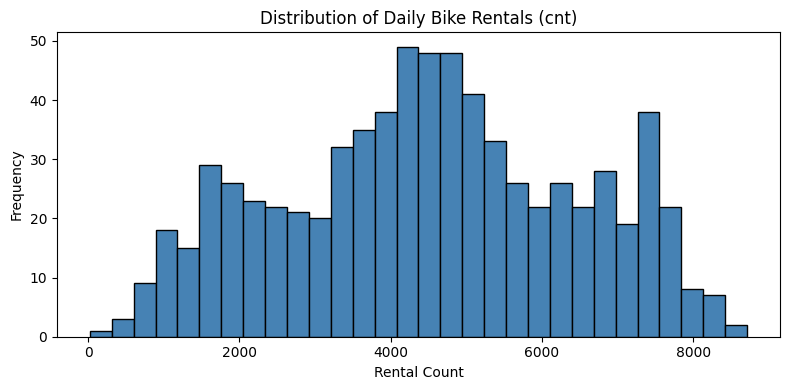

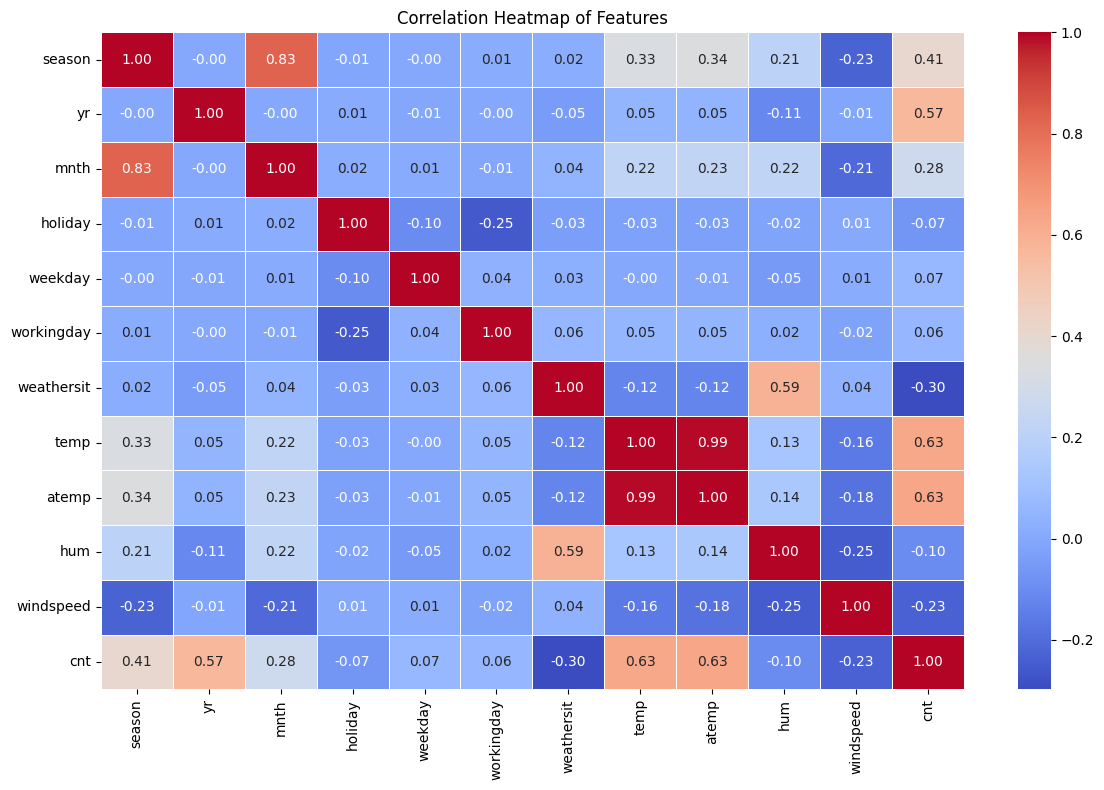

In [ ]:
# --- Histogram of target variable (cnt) ---
plt.figure(figsize=(8, 4))
plt.hist(df['cnt'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Daily Bike Rentals (cnt)')
plt.xlabel('Rental Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150)
plt.show()

# --- Correlation Heatmap ---
# Drop non-numeric / identifier columns before heatmap
cols_to_drop = ['instant', 'dteday', 'casual', 'registered']
# 'casual' + 'registered' are sub-components of 'cnt' → drop to avoid data leakage
df_corr = df.drop(columns=cols_to_drop)

plt.figure(figsize=(12, 8))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Features')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150)
plt.show()


In [ ]:

print("\nColumns after One-Hot Encoding:", df.columns.tolist())

# Define Features (X) and Target (y) ───────────────────
# Remove: identifier, date string, and target leakage columns
drop_cols = ['instant', 'dteday', 'casual', 'registered', 'cnt']
X = df.drop(columns=drop_cols)
y = df['cnt'].values

print(f"\nFeature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Number of features   : {X.shape[1]}")

def predict_rentals(temp, atemp, hum, windspeed,
                    year, month, holiday, workingday, weekday,
                    season_1, season_2, season_3, season_4,
                    weather_1, weather_2, weather_3):

    input_dict = {
        'yr': year, 'mnth': month, 'holiday': holiday,
        'workingday': workingday, 'weekday': weekday,
        'temp': temp, 'atemp': atemp, 'hum': hum,
        'windspeed': windspeed,
        'season_1': season_1, 'season_2': season_2,
        'season_3': season_3, 'season_4': season_4,
        'weathersit_1': weather_1, 'weathersit_2': weather_2,
        'weathersit_3': weather_3,
    }

# Train / Test Split (80% / 20%) ───────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")



Columns after One-Hot Encoding: ['instant', 'dteday', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt', 'season_1', 'season_2', 'season_3', 'season_4', 'weathersit_1', 'weathersit_2', 'weathersit_3']

Feature matrix shape : (731, 16)
Target vector shape  : (731,)
Number of features   : 16

Train size: 584 | Test size: 147


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)   # fit ONLY on train
X_test_scaled  = scaler_X.transform(X_test)         # transform test with train stats

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled  = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

n_features = X_train_scaled.shape[1]
print(f"\nScaling complete. Features: {n_features}")



Scaling complete. Features: 16


In [ ]:
# TASK 2 ─ BUILD THE ANN MODEL

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

def create_ann_model(
    n_features,
    neurons_1=128,
    neurons_2=64,
    dropout_rate=0.2,
    learning_rate=0.001,
    activation='relu',
    l2_lambda=0.0
):
    """
    ANN for regression with:
      - 2 hidden layers (required by task)
      - Input shape matching number of features
      - Output: 1 neuron, linear activation (standard for regression)
      - Dropout for overfitting prevention
      - Optional L2 regularization
    """
    model = Sequential([
        # --- Hidden Layer 1 ---

        Dense(neurons_1,
              activation=activation,
              input_shape=(n_features,),
              kernel_regularizer=l2(l2_lambda)),

         Dropout(dropout_rate),

        # --- Hidden Layer 2 ---
        Dense(neurons_2,
              activation=activation,
              kernel_regularizer=l2(l2_lambda)),
        Dropout(dropout_rate),

        # --- Output Layer ---
       Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mean_squared_error'
    )
    return model

# Quick test
test_model = create_ann_model(n_features)
test_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,497 (41.00 KB)

 Trainable params: 10,497 (41.00 KB)

 Non-trainable params: 0 (0.00 B)


METHOD 1: GRID SEARCH

Trying → neurons=32, lr=0.01, batch=32
  Val Loss: 0.1176

Trying → neurons=32, lr=0.01, batch=64
  Val Loss: 0.1181

Trying → neurons=32, lr=0.001, batch=32
  Val Loss: 0.1462

Trying → neurons=32, lr=0.001, batch=64
  Val Loss: 0.1485

Trying → neurons=64, lr=0.01, batch=32
  Val Loss: 0.1180

Trying → neurons=64, lr=0.01, batch=64
  Val Loss: 0.1211

Trying → neurons=64, lr=0.001, batch=32
  Val Loss: 0.1144

Trying → neurons=64, lr=0.001, batch=64
  Val Loss: 0.1148

Trying → neurons=128, lr=0.01, batch=32
  Val Loss: 0.1110

Trying → neurons=128, lr=0.01, batch=64
  Val Loss: 0.1141

Trying → neurons=128, lr=0.001, batch=32
  Val Loss: 0.1199

Trying → neurons=128, lr=0.001, batch=64
  Val Loss: 0.1272

── Grid Search Results (sorted by val_loss) ──
 neurons  learning_rate  batch_size  val_loss
     128          0.010          32  0.110953
     128          0.010          64  0.114068
      64          0.001          32  0.114418
      64          0.001    

  0%|          | 0/20 [00:00<?, ?it/s]


✅ Best Optuna Val Loss : 0.1071
✅ Best Optuna Params   : {'n_layers': 2, 'neurons': 256, 'dropout_rate': 0.348959763651543, 'learning_rate': 0.004685268486947317, 'activation': 'relu'}

TASK 4: FINAL MODEL TRAINING & EVALUATION
Epoch 1/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.5660 - val_loss: 0.2181
Epoch 2/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3270 - val_loss: 0.1443
Epoch 3/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2021 - val_loss: 0.1139
Epoch 4/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2406 - val_loss: 0.1285
Epoch 5/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1930 - val_loss: 0.1104
Epoch 6/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1888 - val_loss: 0.1134
Epoch 7/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1653 - val_loss: 0.1207
Epoch 8/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1276 - val_loss: 0.1452
Epoch 9/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1340 - val_loss: 0.15

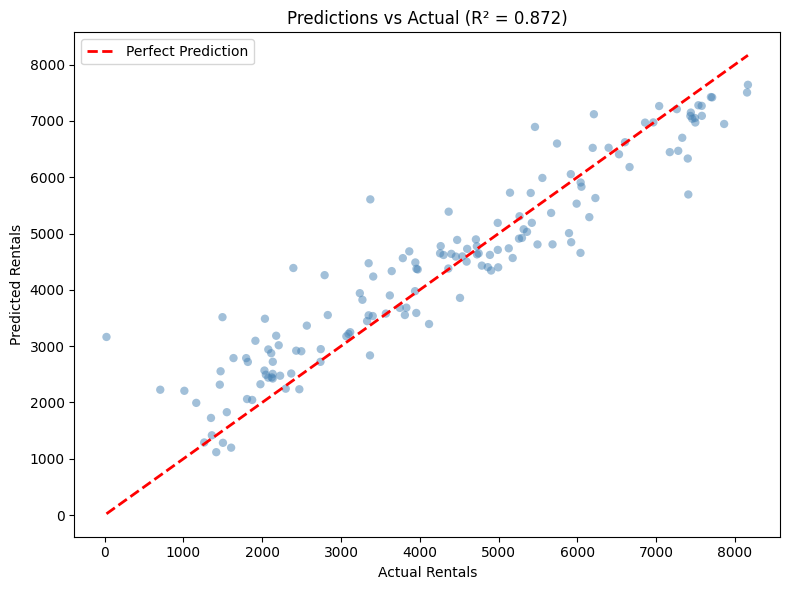

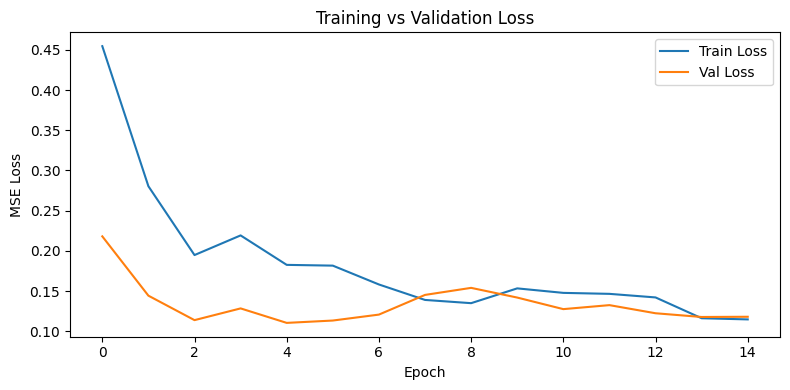

In [ ]:
# TASK 3 ─ HYPERPARAMETER TUNING

# ── METHOD 1: GRID SEARCH ────────────────────────────────────
# We manually loop over every combination of hyperparameters
# and track which gives the lowest validation loss.

print("\n" + "="*60)
print("METHOD 1: GRID SEARCH")
print("="*60)

param_grid = {
    'neurons':        [32, 64, 128],
    'learning_rate':  [0.01, 0.001],
    'batch_size':     [32, 64],
}

early_stop = EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True)

grid_results = []

# Total combinations = 3 × 2 × 2 = 12
for neurons in param_grid['neurons']:
    for lr in param_grid['learning_rate']:
        for bs in param_grid['batch_size']:
            print(f"\nTrying → neurons={neurons}, lr={lr}, batch={bs}")
            model = create_ann_model(n_features,
                                     neurons_1=neurons,
                                     neurons_2=neurons // 2,
                                     learning_rate=lr)
            history = model.fit(
                X_train_scaled, y_train_scaled,
                epochs=50,
                batch_size=bs,
                validation_split=0.2,    # 20% of train used for validation
                callbacks=[early_stop],
                verbose=0
            )
            val_loss = min(history.history['val_loss'])
            grid_results.append({
                'neurons': neurons,
                'learning_rate': lr,
                'batch_size': bs,
                'val_loss': val_loss
            })
            print(f"  Val Loss: {val_loss:.4f}")

# Find best combination
grid_df = pd.DataFrame(grid_results).sort_values('val_loss')
print("\n── Grid Search Results (sorted by val_loss) ──")
print(grid_df.to_string(index=False))
best_grid = grid_df.iloc[0]
print(f"\n✅ Best Grid Search Params: neurons={int(best_grid.neurons)}, "
      f"lr={best_grid.learning_rate}, batch={int(best_grid.batch_size)}")


# ── METHOD 2: BAYESIAN OPTIMIZATION WITH OPTUNA ──────────────
# Optuna is smarter than Grid Search:
# Instead of trying every combination blindly, it builds an
# internal probability model of which hyperparameters work best
# and FOCUSES its search on promising regions.
#
# Trial 1: random guess
# Trial 2: random guess
# Trial 3+: informed guess based on previous results
# This is called Tree-structured Parzen Estimator (TPE).

print("\n" + "="*60)
print("METHOD 2: BAYESIAN OPTIMIZATION (OPTUNA)")
print("="*60)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress noise

def objective(trial):
    """
    Optuna calls this function for each trial.
    It SUGGESTS hyperparameter values and we return the loss.
    Optuna minimizes the returned value.
    """
    # Search space — Optuna picks values within these ranges
    n_layers      = trial.suggest_int('n_layers', 2, 4)
    neurons       = trial.suggest_categorical('neurons', [32, 64, 128, 256])
    dropout_rate  = trial.suggest_float('dropout_rate', 0.1, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    # log=True: searches log scale (better for learning rates)
    activation    = trial.suggest_categorical('activation', ['relu', 'tanh'])

    # Build dynamic model based on trial suggestions
    model = Sequential()
    model.add(Dense(neurons, activation=activation,
                    input_shape=(n_features,)))
    model.add(Dropout(dropout_rate))

    for _ in range(n_layers - 1):
        model.add(Dense(neurons // 2, activation=activation))
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='linear'))
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mean_squared_error')

    early_stop_optuna = EarlyStopping(monitor='val_loss', patience=5,
                                       restore_best_weights=True)
    history = model.fit(
        X_train_scaled, y_train_scaled,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop_optuna],
        verbose=0
    )
    val_loss = min(history.history['val_loss'])
    return val_loss   # Optuna minimizes this

# Run study with 20 trials
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"\n✅ Best Optuna Val Loss : {study.best_value:.4f}")
print(f"✅ Best Optuna Params   : {study.best_params}")


# ============================================================
# TASK 4 ─ TRAIN FINAL MODEL, EVALUATE, PLOT, DEPLOY
# ============================================================

print("\n" + "="*60)
print("TASK 4: FINAL MODEL TRAINING & EVALUATION")
print("="*60)

# ── 4a. Build & train final model with best Optuna params ─────
best = study.best_params

final_model = Sequential()
final_model.add(Dense(best['neurons'],
                      activation=best['activation'],
                      input_shape=(n_features,)))
final_model.add(Dropout(best['dropout_rate']))

for _ in range(best['n_layers'] - 1):
    final_model.add(Dense(best['neurons'] // 2,
                           activation=best['activation']))
    final_model.add(Dropout(best['dropout_rate']))

final_model.add(Dense(1, activation='linear'))
final_model.compile(
    optimizer=Adam(learning_rate=best['learning_rate']),
    loss='mean_squared_error'
)

early_stop_final = EarlyStopping(monitor='val_loss', patience=10,
                                  restore_best_weights=True)

history_final = final_model.fit(
    X_train_scaled, y_train_scaled,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_final],
    verbose=1
)

#Make Predictions ──────────────────────────────────────
y_pred_scaled = final_model.predict(X_test_scaled).flatten()

# Inverse transform back to original bike count scale
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = y_test   # already in original scale

#  Evaluate ──────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print("\n── Business-Ready Metrics ──")
print(f"MAE  : {mae:.1f} bikes")
# "On average, our prediction is off by {mae:.0f} bikes per day."
print(f"RMSE : {rmse:.1f} bikes")
# "Larger errors are penalized more — RMSE > MAE means some days are far off."
print(f"R²   : {r2:.4f}  ({r2*100:.1f}% of variance explained)")
# "Our model explains {r2*100:.0f}% of the variation in daily rentals."

#  Plot: Predictions vs Actual ───────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_true, y_pred, alpha=0.5, color='steelblue', edgecolors='none')
# Perfect prediction line (45-degree)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Rentals')
plt.ylabel('Predicted Rentals')
plt.title(f'Predictions vs Actual (R² = {r2:.3f})')
plt.legend()
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150)
plt.show()

#  Training Loss Curve ───────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(history_final.history['loss'],     label='Train Loss')
plt.plot(history_final.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('training_loss_curve.png', dpi=150)
plt.show()


In [ ]:
# DEPLOY WITH GRADIO

import gradio as gr

# Reconstruct the feature names after one-hot encoding
feature_names = X.columns.tolist()

def predict_rentals(temp, atemp, hum, windspeed,
                    year, month, holiday, workingday, weekday,
                    season_1, season_2, season_3, season_4,
                    weather_1, weather_2, weather_3, weather_4):
    """
    Takes user inputs, builds the feature vector,
    scales it, and returns the predicted rental count.
    """
    # Build input dict matching all feature columns
    input_dict = {
        'yr': year, 'mnth': month, 'holiday': holiday,
        'workingday': workingday, 'weekday': weekday,
        'temp': temp, 'atemp': atemp, 'hum': hum,
        'windspeed': windspeed,
        'season_1': season_1, 'season_2': season_2,
        'season_3': season_3, 'season_4': season_4,
        'weathersit_1': weather_1, 'weathersit_2': weather_2,
        'weathersit_3': weather_3, 'weathersit_4': weather_4,
    }
    # Create a DataFrame with all feature columns (fill missing with 0)
    input_df = pd.DataFrame([input_dict])
    input_df = input_df.reindex(columns=feature_names, fill_value=0)

    # Scale and predict
    input_scaled = scaler_X.transform(input_df)
    pred_scaled  = final_model.predict(input_scaled, verbose=0)
    pred_count   = scaler_y.inverse_transform(pred_scaled)[0][0]

    return f"🚴 Predicted Daily Rentals: {max(0, int(pred_count))} bikes"

# Build the Gradio interface
def predict_rentals(temp, atemp, hum, windspeed,
                    year, month, holiday, workingday, weekday,
                    season_1, season_2, season_3, season_4,
                    weather_1, weather_2, weather_3):

    input_dict = {
        'yr':           int(year),
        'mnth':         int(month),
        'holiday':      int(holiday),
        'workingday':   int(workingday),
        'weekday':      int(weekday),
        'temp':         float(temp),
        'atemp':        float(atemp),
        'hum':          float(hum),
        'windspeed':    float(windspeed),
        'season_1':     bool(season_1),
        'season_2':     bool(season_2),
        'season_3':     bool(season_3),
        'season_4':     bool(season_4),
        'weathersit_1': bool(weather_1),
        'weathersit_2': bool(weather_2),
        'weathersit_3': bool(weather_3),
    }

    input_df = pd.DataFrame([input_dict])
    input_df = input_df.reindex(columns=feature_names, fill_value=0)

    # Make sure dtypes match training data
    for col in ['season_1','season_2','season_3','season_4',
                'weathersit_1','weathersit_2','weathersit_3']:
        input_df[col] = input_df[col].astype(bool)

    input_scaled = scaler_X.transform(input_df)
    pred_scaled  = final_model.predict(input_scaled, verbose=0)
    pred_count   = scaler_y.inverse_transform(pred_scaled)[0][0]

    return f"🚴 Predicted Daily Rentals: {max(0, int(pred_count))} bikes"


iface = gr.Interface(
    fn=predict_rentals,
    inputs=[
        gr.Slider(0.0, 1.0, step=0.01, value=0.5,  label="Temperature (0=cold, 1=hot)"),
        gr.Slider(0.0, 1.0, step=0.01, value=0.5,  label="Feels-like Temp"),
        gr.Slider(0.0, 1.0, step=0.01, value=0.5,  label="Humidity"),
        gr.Slider(0.0, 1.0, step=0.01, value=0.2,  label="Wind Speed"),
        gr.Radio([0, 1],    value=1,                label="Year (0=2011, 1=2012)"),
        gr.Slider(1, 12,    step=1, value=6,        label="Month"),
        gr.Radio([0, 1],    value=0,                label="Holiday? (1=Yes)"),
        gr.Radio([0, 1],    value=1,                label="Working Day? (1=Yes)"),
        gr.Slider(0, 6,     step=1, value=3,        label="Weekday (0=Sun … 6=Sat)"),
        gr.Radio([0, 1],    value=1,                label="Spring? (season_1)"),
        gr.Radio([0, 1],    value=0,                label="Summer? (season_2)"),
        gr.Radio([0, 1],    value=0,                label="Fall?   (season_3)"),
        gr.Radio([0, 1],    value=0,                label="Winter? (season_4)"),
        gr.Radio([0, 1],    value=1,                label="Clear Weather?"),
        gr.Radio([0, 1],    value=0,                label="Misty Weather?"),
        gr.Radio([0, 1],    value=0,                label="Light Snow/Rain?"),
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="🚴 Bike Sharing Demand Predictor",
    description="Fill in weather & date info → get predicted daily rentals.\n⚠️ Only one season and one weather type should be set to 1 at a time."
)

iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://825097263c3ba50119.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
